# Sentiment Analysis using NLP Pipeline & ML Models

# 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saisa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saisa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# 2. Data Understanding

In [2]:
df = pd.read_csv('IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['sentiment'].value_counts())

Dataset Shape: (50000, 2)

Class Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


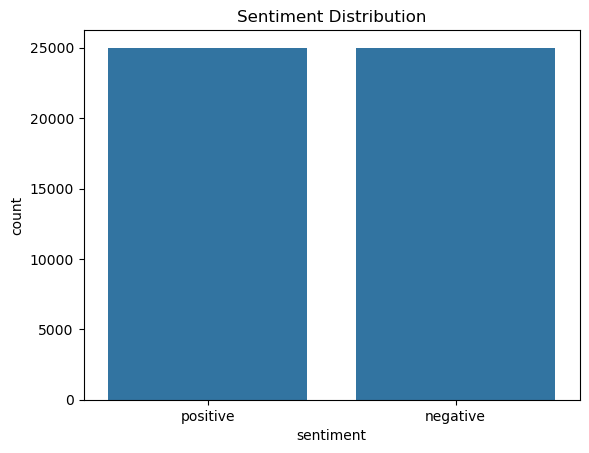

In [4]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [17]:
# Observation:
# Balanced dataset (positive ≈ negative)
# Text is raw and contains noise (HTML tags, punctuation, etc.)

# 3. NLP Preprocessing

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Tokenization
    tokens = text.split()
    
    # Remove stopwords + Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

## Apply Preprocessing

In [6]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


# 4. Feature Engineering


## 4.1 Bag of Words (BoW)

In [7]:
bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df['cleaned_review'])

## 4.2 TF-IDF

In [8]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['cleaned_review'])

## Target Encoding

In [9]:
y = df['sentiment'].map({'positive': 1, 'negative': 0})

# 5. Train-Test Split

In [10]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42)

# 6. Model Building

## We’ll train 3 models on both BoW and TF-IDF.

## 6.1 Logistic Regression

In [11]:
lr = LogisticRegression(max_iter=200)

lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

## 6.2 Naive Bayes

In [12]:
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

## 6.3 Decision Tree

In [13]:
dt = DecisionTreeClassifier()

dt.fit(X_train_tfidf, y_train)
y_pred_dt = dt.predict(X_test_tfidf)

# 7. Model Evaluation

## Logistic Regression

In [14]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8846
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## Naive Bayes

In [15]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8489
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



## Decision Tree

In [16]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7164
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      4961
           1       0.72      0.71      0.72      5039

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



# 6. Comparison & Insights

### In this project, multiple preprocessing techniques, feature engineering methods, and machine learning models were applied to perform sentiment analysis.
### Among preprocessing steps, removing HTML tags, punctuation, stopwords, and applying lemmatization significantly improved text quality by reducing noise and standardizing words. This helped in reducing vocabulary size and improving model learning.
### For feature engineering, TF-IDF performed better than Bag of Words because it assigns importance to meaningful words and reduces the impact of very frequent but less informative words. This resulted in better representation of text data.
### Among the models, Logistic Regression achieved the highest accuracy (88.46%) and provided the most balanced performance across precision, recall, and F1-score. Naive Bayes also performed well as a fast and efficient baseline model, while Decision Tree showed poor performance due to its inability to handle high-dimensional sparse data effectively.
### Overall, the combination of proper preprocessing, TF-IDF vectorization, and Logistic Regression produced the best results for this sentiment analysis task.

# One-Line Conclusion

### The success of this sentiment analysis system primarily depends on effective preprocessing and appropriate feature representation, with TF-IDF and Logistic Regression proving to be the most optimal combination.